In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv("Road Accident Data.csv")
df.head()

,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Jan,Monday,2021,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Jan,Tuesday,2021,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [5]:
df.shape

(307973, 23)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  str    
 1   Accident Date               307973 non-null  str    
 2   Month                       307973 non-null  str    
 3   Day_of_Week                 307973 non-null  str    
 4   Year                        307973 non-null  int64  
 5   Junction_Control            307973 non-null  str    
 6   Junction_Detail             307973 non-null  str    
 7   Accident_Severity           307973 non-null  str    
 8   Latitude                    307973 non-null  float64
 9   Light_Conditions            307973 non-null  str    
 10  Local_Authority_(District)  307973 non-null  str    
 11  Carriageway_Hazards         5424 non-null    str    
 12  Longitude                   307973 non-null  float64
 13  Number_of_Casualties     

In [9]:
df.describe()

,Year,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit
count,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000
mean,2021.468934,52.487005,-1.368884,1.356882,1.829063,38.866037
std,0.499035,1.339011,1.356092,0.815857,0.710477,14.032933
min,2021.000000,49.914488,-7.516225,1.000000,1.000000,10.000000
25%,2021.000000,51.485248,-2.247937,1.000000,1.000000,30.000000
50%,2021.000000,52.225943,-1.349258,1.000000,2.000000,30.000000
75%,2022.000000,53.415517,-0.206810,1.000000,2.000000,50.000000
max,2022.000000,60.598055,1.759398,48.000000,32.000000,70.000000


In [10]:
df.isnull().sum()

Accident_Index                     0
Accident Date                      0
Month                              0
Day_of_Week                        0
Year                               0
Junction_Control                   0
Junction_Detail                    0
Accident_Severity                  0
Latitude                           0
Light_Conditions                   0
Local_Authority_(District)         0
Carriageway_Hazards           302549
Longitude                          0
Number_of_Casualties               0
Number_of_Vehicles                 0
Police_Force                       0
Road_Surface_Conditions          317
Road_Type                       1534
Speed_limit                        0
Time                              17
Urban_or_Rural_Area                0
Weather_Conditions              6057
Vehicle_Type                       0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(1)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop('Carriageway_Hazards',axis=1,inplace=True)


In [15]:
df.dropna(subset=['Time'],inplace=True)

In [19]:
df["Road_Surface_Conditions"]=df["Road_Surface_Conditions"].fillna(df["Road_Surface_Conditions"].mode()[0])

In [20]:
df['Road_Type']=df['Road_Type'].fillna(df['Road_Type'].mode()[0])

In [21]:
df["Weather_Conditions"]=df["Weather_Conditions"].fillna(df["Weather_Conditions"].mode()[0])

In [22]:
df.isnull().sum()

Accident_Index                0
Accident Date                 0
Month                         0
Day_of_Week                   0
Year                          0
Junction_Control              0
Junction_Detail               0
Accident_Severity             0
Latitude                      0
Light_Conditions              0
Local_Authority_(District)    0
Longitude                     0
Number_of_Casualties          0
Number_of_Vehicles            0
Police_Force                  0
Road_Surface_Conditions       0
Road_Type                     0
Speed_limit                   0
Time                          0
Urban_or_Rural_Area           0
Weather_Conditions            0
Vehicle_Type                  0
dtype: int64

In [23]:
df.shape

(307955, 22)

In [26]:
df.columns


Index(['Accident_Index', 'Accident Date', 'Month', 'Day_of_Week', 'Year',
       'Junction_Control', 'Junction_Detail', 'Accident_Severity', 'Latitude',
       'Light_Conditions', 'Local_Authority_(District)', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='str')

In [27]:
df.head()

,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Jan,Monday,2021,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Jan,Tuesday,2021,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [29]:
df['Accident Date']=pd.to_datetime(df['Accident Date'])

In [44]:
df['Accident Date'].dt.year

0         2021
1         2021
2         2021
3         2021
4         2021
          ... 
307968    2022
307969    2022
307970    2022
307971    2022
307972    2022
Name: Accident Date, Length: 307955, dtype: int32

In [37]:
df['Accident Date'].dt.month

0         1
1         1
2         1
3         1
4         1
         ..
307968    2
307969    2
307970    2
307971    2
307972    2
Name: Accident Date, Length: 307955, dtype: int32

In [38]:
df['Accident Date'].dt.day

0          1
1          5
2          4
3          5
4          6
          ..
307968    18
307969    21
307970    23
307971    23
307972    28
Name: Accident Date, Length: 307955, dtype: int32

In [39]:
df['Accident Date'].dt.day_name()

0            Friday
1           Tuesday
2            Monday
3           Tuesday
4         Wednesday
            ...    
307968       Friday
307969       Monday
307970    Wednesday
307971    Wednesday
307972       Monday
Name: Accident Date, Length: 307955, dtype: str

In [45]:
df['Is_Weekend']=df['Day_of_Week'].isin(['Saturday','Sunday'])

In [32]:
df['Is_Weekend'].value_counts()

Is_Weekend
False    232848
True      75107
Name: count, dtype: int64

In [48]:
df['Hour']=pd.to_datetime(df['Time'],format='%H:%M').dt.hour

In [49]:
df['Hour'].head()

0    15
1    10
2    14
3     8
4    17
Name: Hour, dtype: int32

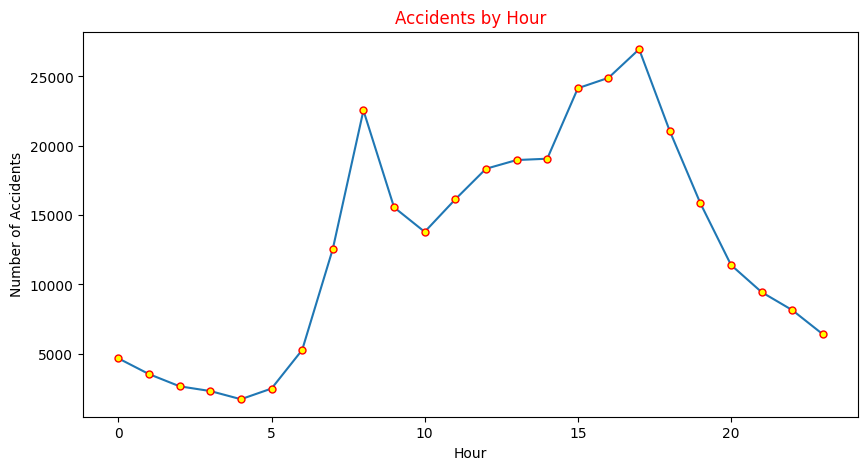

In [54]:
hourly = df.groupby('Hour').size()

plt.figure(figsize=(10,5))

hourly.plot(marker='o',markersize=5,markerfacecolor='yellow',markeredgecolor='red')

plt.title("Accidents by Hour",color='red')
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")

plt.show()

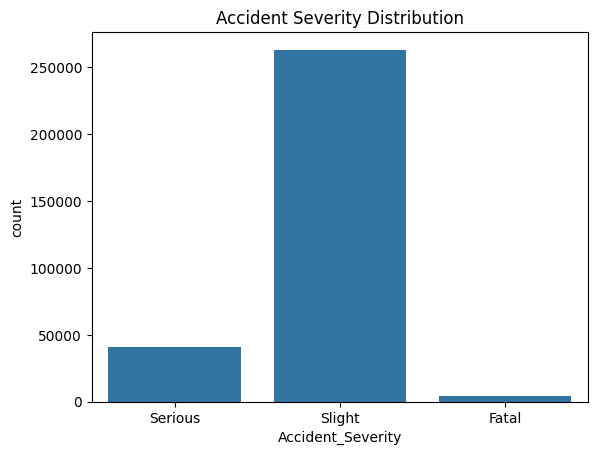

In [55]:
sns.countplot(data=df, x='Accident_Severity')

plt.title("Accident Severity Distribution")
plt.show()

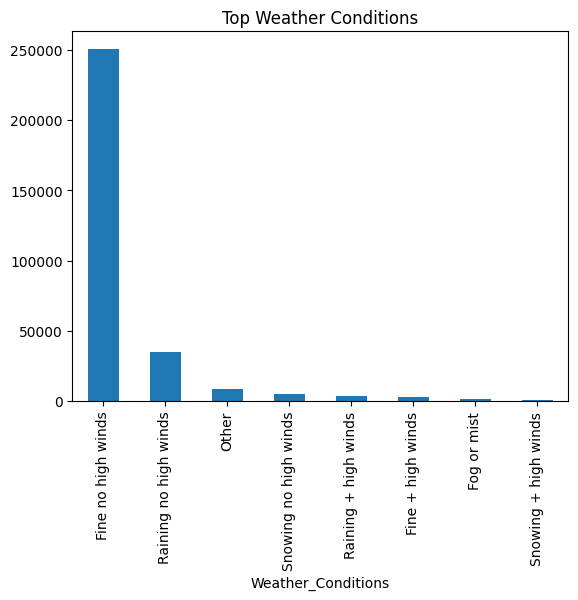

In [56]:
weather = df['Weather_Conditions'].value_counts().head(10)

weather.plot(kind='bar')

plt.title("Top Weather Conditions")
plt.show()

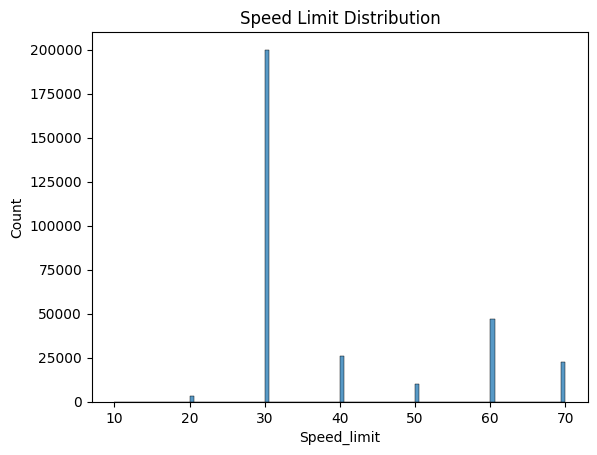

In [57]:
sns.histplot(df['Speed_limit'])

plt.title("Speed Limit Distribution")
plt.show()

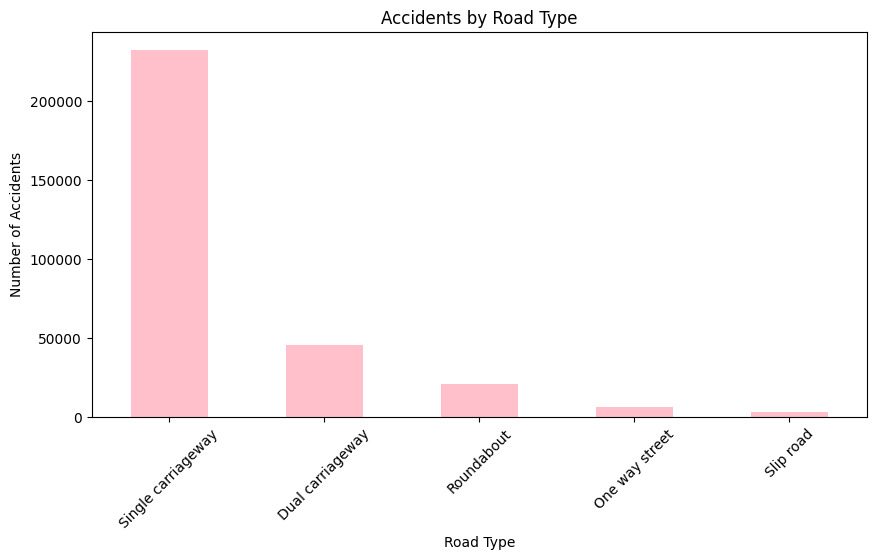

In [61]:
road = df['Road_Type'].value_counts()

plt.figure(figsize=(10,5))

road.plot(kind='bar',color='pink')

plt.title("Accidents by Road Type")
plt.xlabel("Road Type")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)

plt.show()

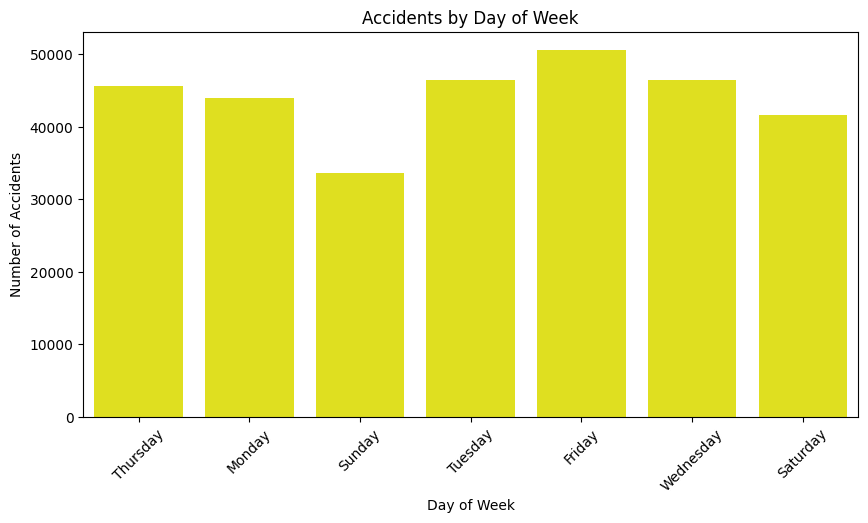

In [63]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='Day_of_Week',color='yellow')

plt.title("Accidents by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)

plt.show()

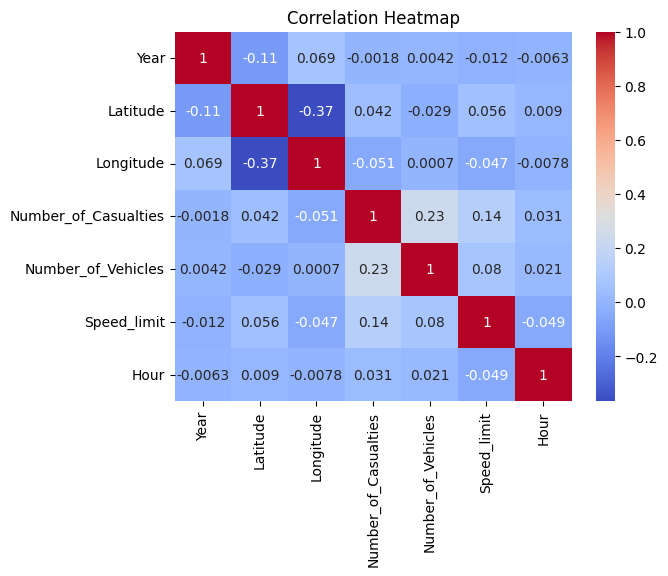

In [64]:
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

**INSIGHTS**

1)The majority of road accidents were classified as Slight severity, accounting for most of the recorded incidents. Serious accidents occurred less frequently, while Fatal accidents represented only a very small proportion of total cases. This suggests that although accidents are common, most result in minor injuries rather than life-threatening consequences.
2)